In [ ]:
"""Supp Fig 17: Ablation Study and Supp Fig 19: Variation across different seeds"""

In [1]:
# import libraries

import glob, os
from PIL import Image
import matplotlib.pyplot as plt
from cldm.preprocess import preprocess_experimental_backgroundwhite, preprocess_simulation_graybackground
from cldm.config import SIM_FOLDER_TEST,EXP_FOLDER_TEST, MAIN_FOLDER,ABLATION_1, ABLATION_2, ABLATION_3, ABLATION_4, ABLATION_5, ABLATION_6, ABLATION_7

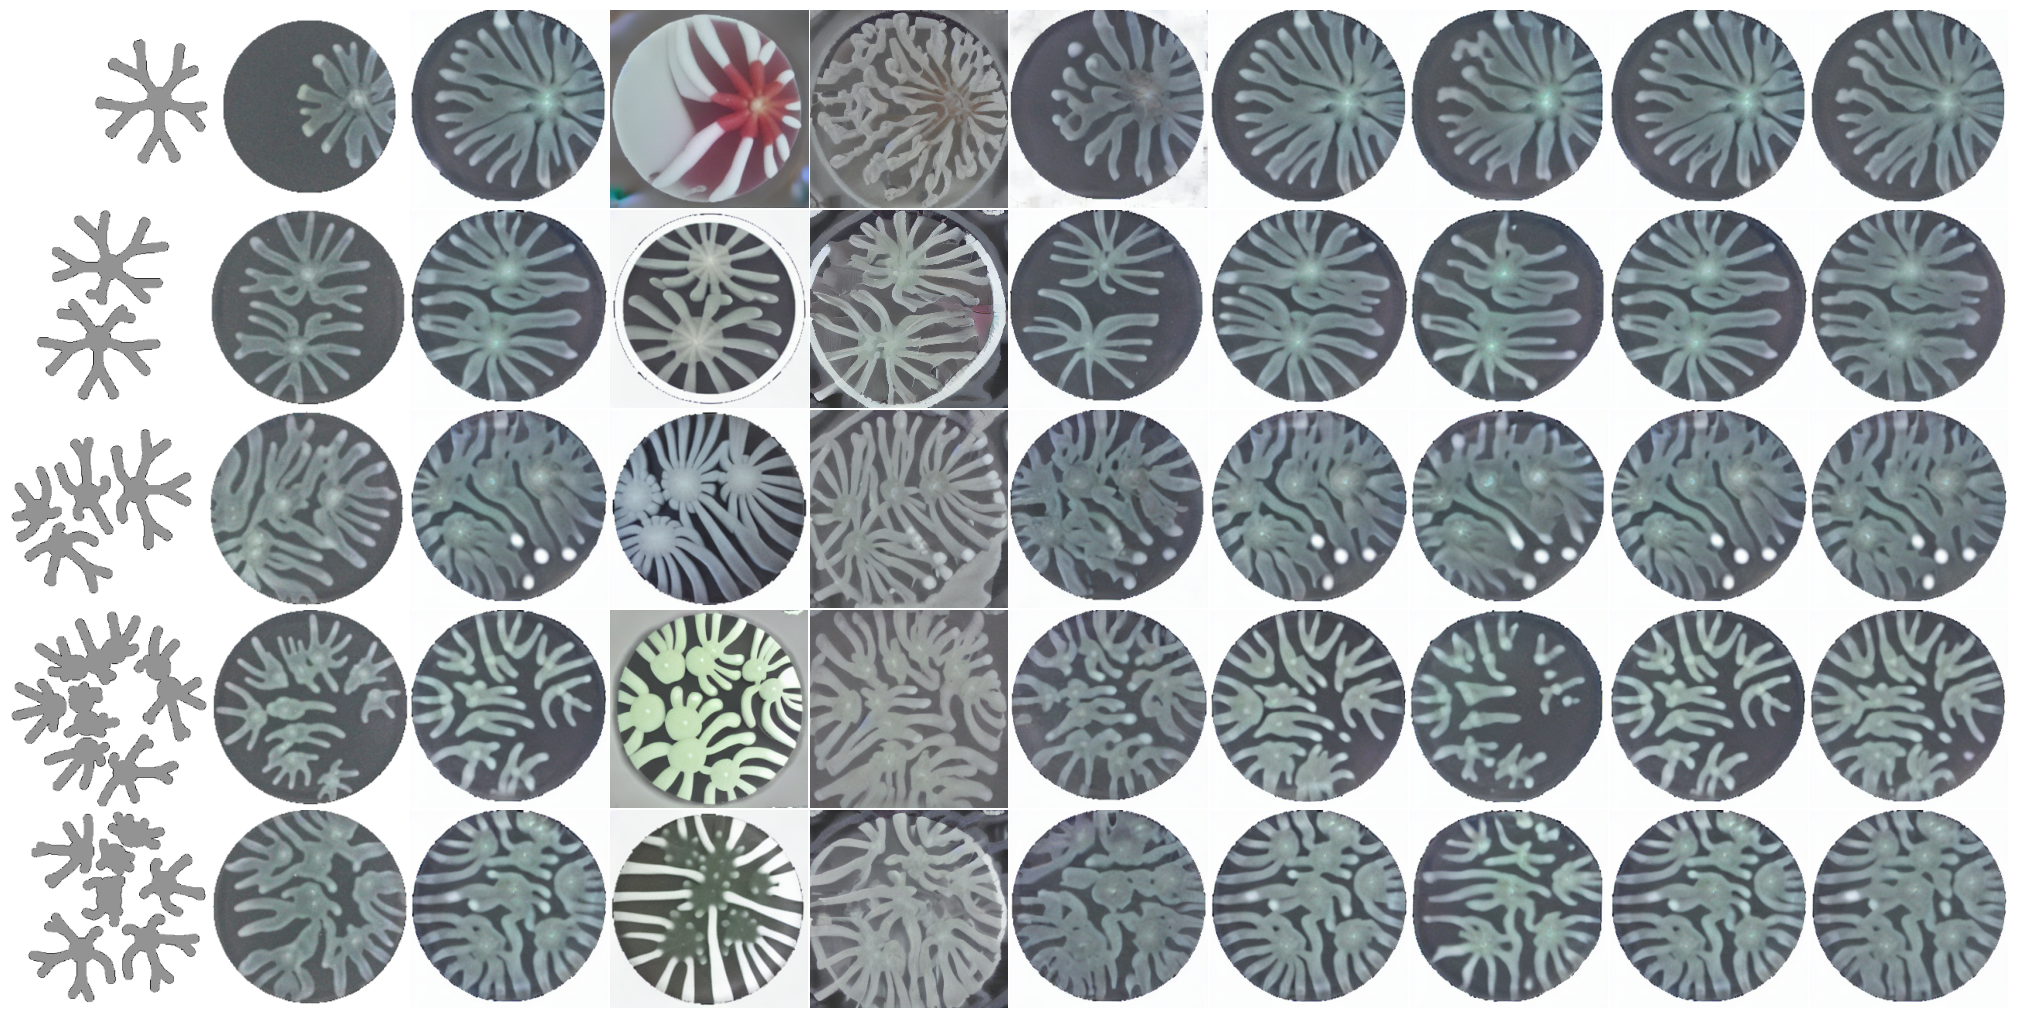

In [2]:
"""Plot from inference folders saved from the inference of trained ControlNet model on test set
for ablation study- testing different hyperparameters in inference mode"""

# CONFIG
sample_ids = [198, 196, 200,227,245]     # your condition IDs
# define your 7 folders (sim, exp, main, then 4 ablations)
folders = {
    "sim":  SIM_FOLDER_TEST,
    "exp":  EXP_FOLDER_TEST, 
    "main": MAIN_FOLDER,
    'ab1':  ABLATION_1,  # Guess_mode= TRUE
    'ab2':  ABLATION_2, # n_prompt=""
    'ab3':  ABLATION_3, # a_prompt="best quality, extremely detailed" # default ControlNet
    'ab4':  ABLATION_4, # strength=0.85
    'ab5':  ABLATION_5, # strength=1.25
    'ab6':  ABLATION_6, # ddim_steps=100
    'ab7':  ABLATION_7  # guidance_scale=9.0 # default ControlNet

}
order = ['sim','exp','main','ab1','ab2','ab3','ab4','ab5','ab6','ab7']

# PLOT
ncols = len(order)
fig, axes = plt.subplots(
    len(sample_ids), ncols,
    figsize=(ncols*2, len(sample_ids)*2),
    layout='constrained'
)

for i, sid in enumerate(sample_ids):
    for j, key in enumerate(order):

        folder = folders[key]
        pattern = os.path.join(folder, f"{sid}_1*")
        matches = sorted(glob.glob(pattern))
        if not matches:
            raise FileNotFoundError(f"No file for {sid} in {key}")
        
        # Pass the file path, not the opened image
        if order[j]=='exp':
            img = preprocess_experimental_backgroundwhite(matches[0])  # 
        elif order[j]=='sim':
            img = preprocess_simulation_graybackground(matches[0])  #
        else:
            img = Image.open(matches[0])  # For other cases, use PIL
            
        axes[i, j].imshow(img,cmap='gray')
        

        axes[i, j].axis('off')
       



fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01, hspace=0.01,
                            wspace=0.01)
plt.show()
